In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df_ipac = pd.read_csv('hosts_ops.csv')
df_ipac = df_ipac[['pl_orbper', 'st_mass']]
df_ipac = df_ipac[df_ipac['pl_orbper']<1e8]
df_ipac['planet_mass'] = np.random.normal(loc=2, scale=10, size=len(df_ipac))
df_ipac['planet_mass'] = df_ipac['planet_mass']*-1
df_ipac['env_mass'] = df_ipac['planet_mass']*0.04
df_ipac = df_ipac[df_ipac['planet_mass']<-0.1]
df_ipac
df_ipac.to_csv('params2.txt', sep='\t', index=False)
#plt.hist(df_ipac['pl_orbper'])

(array([  31.,   82.,   78.,  127.,  108.,   99.,  142.,  193.,  195.,
         290.,  401.,  761.,  583.,  541.,  664.,  923., 1204., 1948.,
        2072., 2026., 2871., 2457., 2647., 2014.,  957., 1056.,  647.,
         412.,  422.,  226.]),
 array([0.01      , 0.05633333, 0.10266667, 0.149     , 0.19533333,
        0.24166667, 0.288     , 0.33433333, 0.38066667, 0.427     ,
        0.47333333, 0.51966667, 0.566     , 0.61233333, 0.65866667,
        0.705     , 0.75133333, 0.79766667, 0.844     , 0.89033333,
        0.93666667, 0.983     , 1.02933333, 1.07566667, 1.122     ,
        1.16833333, 1.21466667, 1.261     , 1.30733333, 1.35366667,
        1.4       ]),
 <BarContainer object of 30 artists>)

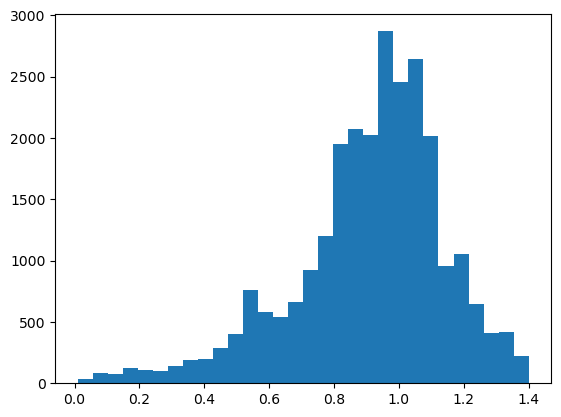

In [3]:
df_hosts = pd.read_csv('STELLARHOSTS_2024.12.03_10.58.46.csv')

df_hosts
plt.hist(df_hosts['st_mass'], bins=30)

(array([1.000e+00, 1.000e+00, 3.000e+00, 5.000e+00, 8.000e+00, 1.000e+01,
        8.000e+00, 1.400e+01, 3.300e+01, 3.800e+01, 8.800e+01, 9.600e+01,
        1.360e+02, 1.930e+02, 2.300e+02, 3.100e+02, 4.310e+02, 5.310e+02,
        6.660e+02, 7.720e+02, 9.240e+02, 1.059e+03, 1.208e+03, 1.379e+03,
        1.529e+03, 1.604e+03, 1.625e+03, 1.663e+03, 1.752e+03, 1.743e+03]),
 array([-1.67411738, -1.61844945, -1.56278151, -1.50711358, -1.45144564,
        -1.39577771, -1.34010977, -1.28444184, -1.2287739 , -1.17310597,
        -1.11743804, -1.0617701 , -1.00610217, -0.95043423, -0.8947663 ,
        -0.83909836, -0.78343043, -0.72776249, -0.67209456, -0.61642662,
        -0.56075869, -0.50509075, -0.44942282, -0.39375488, -0.33808695,
        -0.28241901, -0.22675108, -0.17108314, -0.11541521, -0.05974727,
        -0.00407934]),
 <BarContainer object of 30 artists>)

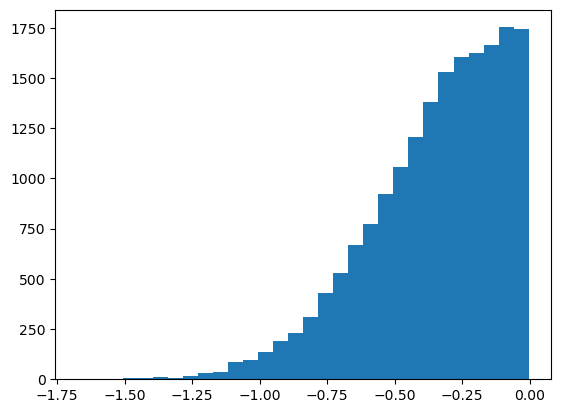

In [6]:
plt.hist(df_ipac['env_mass'], bins=30)

In [4]:
#df_orb_periods = pd.read_csv('PS_2025.02.04_19.13.43.csv')
# pers = df_orb_periods['pl_orbper']
# print(len(pers))
# pers1 = pers.dropna()
# print(len(pers1))
# plt.hist(df_orb_periods['pl_orbper'])

In [5]:
def loguniform(low=0, high=1, size=None):
    return np.exp(np.random.uniform(low, high, size))

In [6]:

# Create a DataFrame
df = pd.DataFrame({})
size=10000
# Add a column with values from a Gaussian distribution
#df['stellar_mass'] = np.random.normal(loc=1, scale=0.5, size=size)
df['stellar_mass']=np.random.choice(df_hosts['st_mass'], size=size)
df['orb_period']=np.random.uniform(10, 60, size=size) #changed from 10-50 to 100
#df['planet_mass'] = np.random.normal(loc=2, scale=10, size=size)
df['planet_mass'] = np.random.rayleigh(scale=3, size=size)
#df['env_mass'] = df['planet_mass']*0.04
df['env_mass'] = loguniform(0.01, 0.3, size=size)
# loc: Mean of the distribution (default is 0)
# scale: Standard deviation (default is 1)
# size: Number of values to generate (here, same as the length of the DataFrame)
df_total = df
df_min = df[(df['planet_mass']<0.1)|(df['stellar_mass']<0.1)|(df['orb_period']<1e8)]
while len(df_min)>0:
    df=df[(df['planet_mass']>=0.1)&(df['stellar_mass']>=0.1)&(df['stellar_mass']<1.4)]
    df_new = pd.DataFrame({})
    df_new['stellar_mass'] = np.random.normal(loc=1, scale=0.5, size=len(df_min))
    df_new['planet_mass'] = np.random.normal(loc=2.0, scale=1.15, size=len(df_min))
    df_new['env_mass'] = df_new['planet_mass']*0.1 #*0.04
    df_new['orb_period'] = np.random.uniform(10, 50, size=len(df_min))
    #df_new['orb_period'] = np.random.choice(df_orb_periods['pl_orbper'], size=len(df_min))
    
    df = pd.concat([df, df_new], ignore_index=True, sort=False)
    print(df)
    df_min = df[(df['planet_mass']<0.1)|(df['stellar_mass']<0.1)]
    
    

df
# Save the array as an .npy file
#df.to_csv('params.txt', sep='\t', index=False)

       stellar_mass  orb_period  planet_mass  env_mass
0          1.080000   18.617505     3.607079  1.239028
1          0.710000   43.092441     3.071040  1.172749
2          1.080000   42.859917     1.283284  1.126159
3          0.770000   49.871181     5.304082  1.184531
4          0.930000   35.109640     1.110167  1.192072
...             ...         ...          ...       ...
19940      1.016606   22.665288     0.767568  0.076757
19941      1.497171   37.388707     2.273464  0.227346
19942      0.258478   46.165736     3.511741  0.351174
19943      1.255591   45.568040     0.375845  0.037584
19944      1.102856   34.307133     0.931229  0.093123

[19945 rows x 4 columns]
       stellar_mass  orb_period  planet_mass  env_mass
0          1.080000   18.617505     3.607079  1.239028
1          0.710000   43.092441     3.071040  1.172749
2          1.080000   42.859917     1.283284  1.126159
3          0.770000   49.871181     5.304082  1.184531
4          0.930000   35.109640     1.1

,stellar_mass,orb_period,planet_mass,env_mass
0,1.080000,18.617505,3.607079,1.239028
1,0.710000,43.092441,3.071040,1.172749
2,1.080000,42.859917,1.283284,1.126159
3,0.770000,49.871181,5.304082,1.184531
4,0.930000,35.109640,1.110167,1.192072
...,...,...,...,...
17730,0.555737,30.161352,2.853305,0.285330
17731,0.513032,26.833765,1.572960,0.157296
17732,0.995955,39.713866,2.007847,0.200785
17733,1.882748,17.809355,1.754838,0.175484


In [7]:
df.dropna()

,stellar_mass,orb_period,planet_mass,env_mass
0,1.080000,18.617505,3.607079,1.239028
1,0.710000,43.092441,3.071040,1.172749
2,1.080000,42.859917,1.283284,1.126159
3,0.770000,49.871181,5.304082,1.184531
4,0.930000,35.109640,1.110167,1.192072
...,...,...,...,...
17730,0.555737,30.161352,2.853305,0.285330
17731,0.513032,26.833765,1.572960,0.157296
17732,0.995955,39.713866,2.007847,0.200785
17733,1.882748,17.809355,1.754838,0.175484


In [8]:
add = {'stellar_mass':1.0, 'planet_mass':1.0, 'env_mass':0.1, 'orb_period':30}
df.loc[len(df)] = add
df['planet_mass']=df['planet_mass']*-1
df['env_mass']=df['env_mass']*-1
df['orb_period']=df['orb_period']*-1
df

,stellar_mass,orb_period,planet_mass,env_mass
0,1.080000,-18.617505,-3.607079,-1.239028
1,0.710000,-43.092441,-3.071040,-1.172749
2,1.080000,-42.859917,-1.283284,-1.126159
3,0.770000,-49.871181,-5.304082,-1.184531
4,0.930000,-35.109640,-1.110167,-1.192072
...,...,...,...,...
17731,0.513032,-26.833765,-1.572960,-0.157296
17732,0.995955,-39.713866,-2.007847,-0.200785
17733,1.882748,-17.809355,-1.754838,-0.175484
17734,0.437629,-45.543995,-3.785254,-0.378525


In [9]:
df.to_csv('params3.txt', sep='\t', index=False)